In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path('../').resolve()))
from src.training_viz import plot_training_curves

# Auto-resolve: pick the most recently modified run folder (same pattern as 04_model_evaluation).
# Override RUN_TAG manually to visualize a specific run.
runs_root = Path('../models/runs')
RUN_TAG = globals().get('RUN_TAG', None)

if RUN_TAG is None:
    assert runs_root.exists(), f"Missing runs directory: {runs_root}"
    run_dirs = sorted(
        [p for p in runs_root.iterdir() if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    assert run_dirs, f"No run folders found in {runs_root}"
    run_dir = run_dirs[0]
    RUN_TAG = run_dir.name
else:
    run_dir = runs_root / RUN_TAG

print('RUN_TAG:', RUN_TAG)
print('run_dir:', run_dir)

RUN_TAG: 20260321_214623
run_dir: ../models/runs/20260321_214623


Saved training_curves.png to ../models/runs/20260321_214623


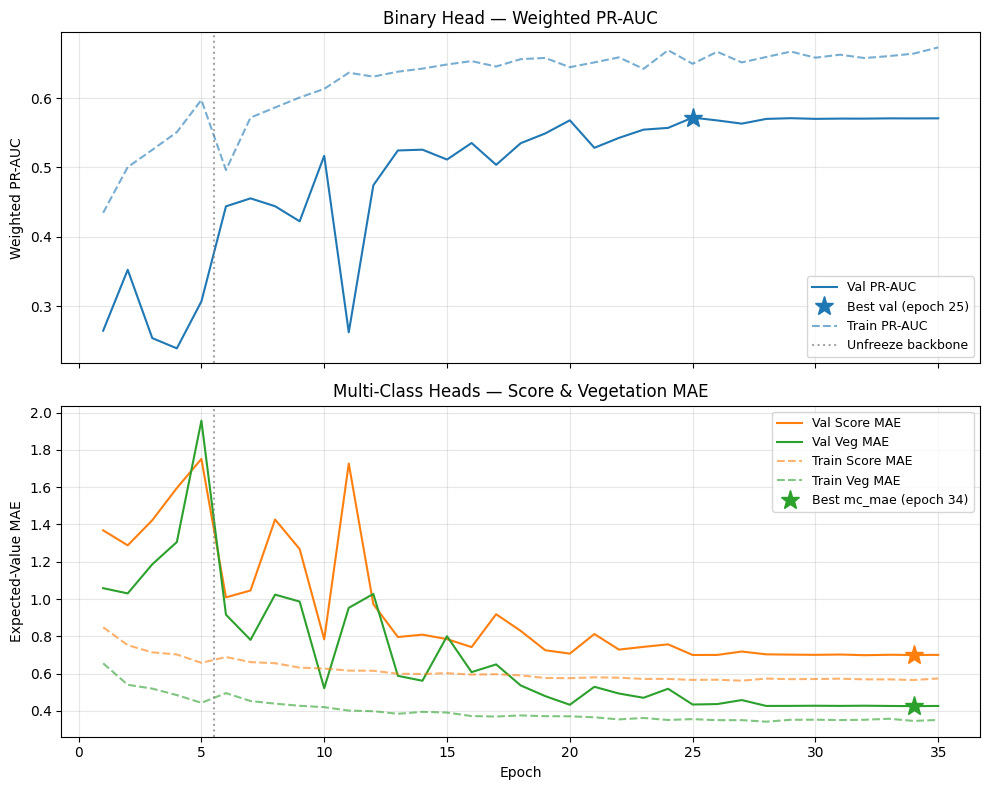

In [2]:
with open(run_dir / f'training_history_{RUN_TAG}.json') as f:
    history = json.load(f)
with open(run_dir / f'model_config_{RUN_TAG}.json') as f:
    config = json.load(f)

plot_training_curves(history, warmup_epochs=config['warmup_epochs'], save_dir=run_dir)